<a href="https://colab.research.google.com/github/AndrewLoweUoM/Hydrological_Analysis/blob/main/Single_Event_Analysis_Peaks_Timings_Lags_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Description of Code:

This code performs a detailed single-event hydrological analysis, extracting peak flow, rainfall characteristics, and lag times (including centroid-based metrics), and organising them into a structured output.

This script performs detailed single-event hydrological analysis using an already aligned (adjusted) storm event dataset, focusing on:

* Visualising one storm event
* Extracting key hydrological metrics
* Calculating lag times
* Computing rainfall centroid.

Overall, this code performs a detailed single-event hydrological analysis, extracting peak flow, rainfall characteristics, and lag times (including centroid-based metrics), and organising them into a structured output.

# Data Loading & Inspection

### Load adjusted data into Dataframe & Checks Data

In [ ]:
# Load the data using pandas
import pandas as pd # pandas for data manipulation
import matplotlib.pyplot as plt # import the pyplot module from matplotlib
from matplotlib.dates import DateFormatter
import numpy as np # numpy for numerical operations

# Load the data
file_path ='/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Oak_storm_event_timeseries_23_events_adjusted.csv'
#file_path ='/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Bollin_storm_event_timeseries_all_events_adjusted.csv'

df1 = pd.read_csv(file_path)

# Displays start data in the Dataframe
df1.head()

,Time,Event001_Time,Event001_Rain,Event001_Flow,Event001_Baseflow,Event002_Time,Event002_Rain,Event002_Flow,Event002_Baseflow,Event003_Time,...,Event020_Flow,Event020_Baseflow,Event021_Time,Event021_Rain,Event021_Flow,Event021_Baseflow,Event022_Time,Event022_Rain,Event022_Flow,Event022_Baseflow
0,1,26/07/2023 20:30,1.4,11.0,9.3,02/08/2023 03:15,0.6,17.4,14.7,14/08/2023 09:45,...,26.5,20.4,22/05/2024 09:30,0.4,8.2,7.1,09/06/2024 19:15,0.2,10.7,9.0
1,2,26/07/2023 20:45,1.6,11.6,9.3,02/08/2023 03:30,1.0,18.1,14.4,14/08/2023 10:00,...,27.3,20.4,22/05/2024 09:45,0.6,10.2,7.1,09/06/2024 19:30,0.4,11.3,9.0
2,3,26/07/2023 21:00,1.2,11.9,9.3,02/08/2023 03:45,0.2,20.5,14.4,14/08/2023 10:15,...,28.3,20.4,22/05/2024 10:00,7.6,10.6,7.1,09/06/2024 19:45,0.6,12.1,9.0
3,4,26/07/2023 21:15,0.8,12.0,9.3,02/08/2023 04:00,0.2,23.0,14.4,14/08/2023 10:30,...,30.0,20.4,22/05/2024 10:15,1.0,11.9,7.1,09/06/2024 20:00,0.6,11.6,9.0
4,5,26/07/2023 21:30,0.4,12.6,9.3,02/08/2023 04:15,0.2,25.3,14.2,14/08/2023 10:45,...,24.7,20.4,22/05/2024 10:30,0.8,10.6,7.1,09/06/2024 20:15,1.2,12.3,9.0


#### Review data in DataFrame by Checking Head, Tail, and Shape

In [ ]:
# Displays start data in the Dataframe
df1.head()

,Time,Event001_Time,Event001_Rain,Event001_Flow,Event001_Baseflow,Event002_Time,Event002_Rain,Event002_Flow,Event002_Baseflow,Event003_Time,...,Event020_Flow,Event020_Baseflow,Event021_Time,Event021_Rain,Event021_Flow,Event021_Baseflow,Event022_Time,Event022_Rain,Event022_Flow,Event022_Baseflow
0,1,26/07/2023 20:30,1.4,11.0,9.3,02/08/2023 03:15,0.6,17.4,14.7,14/08/2023 09:45,...,26.5,20.4,22/05/2024 09:30,0.4,8.2,7.1,09/06/2024 19:15,0.2,10.7,9.0
1,2,26/07/2023 20:45,1.6,11.6,9.3,02/08/2023 03:30,1.0,18.1,14.4,14/08/2023 10:00,...,27.3,20.4,22/05/2024 09:45,0.6,10.2,7.1,09/06/2024 19:30,0.4,11.3,9.0
2,3,26/07/2023 21:00,1.2,11.9,9.3,02/08/2023 03:45,0.2,20.5,14.4,14/08/2023 10:15,...,28.3,20.4,22/05/2024 10:00,7.6,10.6,7.1,09/06/2024 19:45,0.6,12.1,9.0
3,4,26/07/2023 21:15,0.8,12.0,9.3,02/08/2023 04:00,0.2,23.0,14.4,14/08/2023 10:30,...,30.0,20.4,22/05/2024 10:15,1.0,11.9,7.1,09/06/2024 20:00,0.6,11.6,9.0
4,5,26/07/2023 21:30,0.4,12.6,9.3,02/08/2023 04:15,0.2,25.3,14.2,14/08/2023 10:45,...,24.7,20.4,22/05/2024 10:30,0.8,10.6,7.1,09/06/2024 20:15,1.2,12.3,9.0


In [ ]:
# Displays end data in the Dataframe
df1.tail()

,Time,Event001_Time,Event001_Rain,Event001_Flow,Event001_Baseflow,Event002_Time,Event002_Rain,Event002_Flow,Event002_Baseflow,Event003_Time,...,Event020_Flow,Event020_Baseflow,Event021_Time,Event021_Rain,Event021_Flow,Event021_Baseflow,Event022_Time,Event022_Rain,Event022_Flow,Event022_Baseflow
601,602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
602,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
603,604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
604,605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
605,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Displays DataFrame dimensions (rows and columns)
print('Shape of data:', df1.shape)

Shape of data: (606, 89)


In [ ]:
# Displays all columnns in the DataFrame
#print(df1.columns)

In [ ]:
# Check for missing values in the DataFrame
#print(df1.isnull().sum())

In [ ]:
#replace null values with 0
#df1.fillna(0, inplace=True)

In [ ]:
# Display summary statistics of the DataFrame
#print(df1.describe())

# Event Visualisation

### Plots Selected Hydrograph (e.g. Event001)

In [ ]:
date=df1['Event001_Time']
flow=df1['Event001_Flow']
rain=df1['Event001_Rain']
#time=df1['Time']

### Plot the event hydrograph and associated rainfall

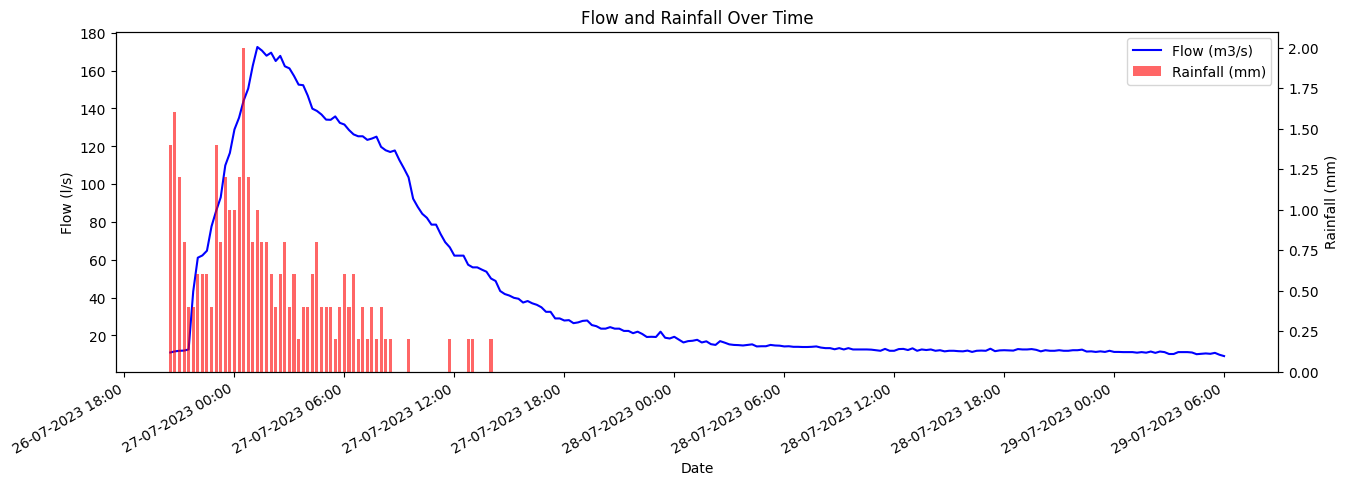

In [ ]:
# Ensure 'Event001_Time' is in datetime format for proper plotting
datetime = pd.to_datetime(date, errors='coerce', dayfirst=True)

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(15, 5))

# Plot 'Flow' on the first y-axis
ax1.plot(datetime, flow, color='blue', label='Flow (l/s)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Flow (l/s)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create a second y-axis
ax2 = ax1.twinx()
# Plot 'Rain' on the second y-axis as bars
ax2.bar(datetime, rain, color='red', alpha=0.6, label='Rainfall (mm)', width=pd.Timedelta(minutes=10))
ax2.set_ylabel('Rainfall (mm)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Set title and add legends
plt.title('Flow and Rainfall Over Time')
fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

# Set x-axis date format to show full date and time
date_form = DateFormatter('%d-%m-%Y %H:%M')
ax1.xaxis.set_major_formatter(date_form)

# Improve date formatting on x-axis
fig.autofmt_xdate()

plt.show()

# Peak Flow and Rainfall Analysis

Calculates:
* Peak flow value
* Time of peak flow

Calculates:
Computes:
* Peak rainfall (before flow peak)
* Time of peak rainfall
* Total rainfall before peak
* Total rainfall during event

### Single Event:

* Calculate time of rainfall and flow peak and peak rainfall and flow value

In [ ]:
import matplotlib.pyplot as plt # for plotting a graph.
import pandas as pd # for data manipulation.
import numpy as np # numpy for numerical operations
from matplotlib.dates import DateFormatter

# Ensure 'Event001_Time' is in datetime format for proper plotting
date = pd.to_datetime(date, errors='coerce', dayfirst=True)

# Calculate time of flow peak and peak flow value
peak_flow_value = flow.max()
# Convert the peak_flow_time directly to datetime
peak_flow_time = pd.to_datetime(df1.loc[flow == peak_flow_value, date.name].iloc[0], dayfirst=True)

print(f"Time of Flow Peak: {peak_flow_time}")
print(f"Peak Flow Value: {peak_flow_value} m3/s")

## Calculate time of rainfall peak and peak rainfall value before or at flow peak
# Filter data to only include times before or at the peak flow using the datetime 'date'
rainfall_before_peak_flow_df = df1[date <= peak_flow_time].copy()

if not rainfall_before_peak_flow_df.empty:
    peak_rainfall_value_before_flow_peak = rainfall_before_peak_flow_df[rain.name].max()
    # Correct column name to 'Event001_Time' and convert to datetime
    peak_rainfall_time_before_flow_peak = pd.to_datetime(rainfall_before_peak_flow_df.loc[rainfall_before_peak_flow_df[rain.name] == peak_rainfall_value_before_flow_peak, date.name].iloc[0], dayfirst=True)

    print(f"Time of Rainfall Peak (before or at flow peak): {peak_rainfall_time_before_flow_peak}")
    print(f"Peak Rainfall Value (before or at flow peak): {peak_rainfall_value_before_flow_peak} mm")
else:
    print("No rainfall recorded before or at the flow peak.")
    # Set to None if no rainfall data to prevent further errors
    peak_rainfall_time_before_flow_peak = None


# Calculate total rainfall before peak flow
if not rainfall_before_peak_flow_df.empty:
    total_rainfall_before_peak = rainfall_before_peak_flow_df[rain.name].sum()
    print(f"Total Rainfall Before Flow Peak: {total_rainfall_before_peak:.2f} mm")
else:
    print("No rainfall data available before the flow peak to calculate total rainfall.")


# Calculate total rainfall during event
total_rainfall = rain.sum()
print(f"Total Rainfall: {total_rainfall:.2f} mm")


Time of Flow Peak: 2023-07-27 01:15:00
Peak Flow Value: 172.5 m3/s
Time of Rainfall Peak (before or at flow peak): 2023-07-27 00:30:00
Peak Rainfall Value (before or at flow peak): 2.0 mm
Total Rainfall Before Flow Peak: 19.60 mm
Total Rainfall: 33.60 mm


# Lag Time Calculation

In [ ]:
# Calculate lag time
if peak_flow_time is not None and peak_rainfall_time_before_flow_peak is not None:
    lag_time = peak_flow_time - peak_rainfall_time_before_flow_peak
    # Convert Timedelta to total hours and format to 2 decimal places
    lag_time_hours = lag_time.total_seconds() / 3600
    print(f"Rainfall to Flow Lag Time: {lag_time_hours:.2f} hours")
else:
    print("Lag time cannot be calculated due to missing peak time data.")
    lag_time = None

Rainfall to Flow Lag Time: 0.75 hours


### Single Event (Centroid):

* Calculate time of rainfall centroid and flow peak and peak rainfall and flow value

### Rainfall Centroid Calculation

Method:

Converts time → seconds
Uses weighted average:

centroid
= ∑
(
𝑡
⋅
𝑟
𝑎
𝑖
𝑛
𝑓
𝑎
𝑙
𝑙
)
∑
𝑟
𝑎
𝑖
𝑛
𝑓
𝑎
𝑙
𝑙
centroid=
∑rainfall
∑(t⋅rainfall)
	​

Steps:
* Remove NaNs
* Convert datetime → numeric time
* Weight by rainfall intensity
* Convert back to datetime

Outputs:
* Rainfall centroid time
* Lag between centroid and flow peak

In [ ]:
# Ensure 'Event001_Time' is in datetime format and 'Event001_Rain' is numeric for centroid calculation
rainfall_before_peak_flow_df_copy = rainfall_before_peak_flow_df.copy()
rainfall_before_peak_flow_df_copy[date.name] = pd.to_datetime(rainfall_before_peak_flow_df_copy[date.name], errors='coerce', dayfirst=True)

# Calculate the centroid of rainfall
# Convert datetime to numerical representation (e.g., seconds since epoch) for calculation
# Filter out NaN values in rainfall as they would skew the centroid calculation
rainfall_for_centroid = rainfall_before_peak_flow_df_copy.dropna(subset=[rain.name])

if not rainfall_for_centroid.empty:
    time_in_seconds = (rainfall_for_centroid[date.name] - rainfall_for_centroid[date.name].min()).dt.total_seconds()

    # If all rainfall values are zero, centroid calculation is not meaningful
    if rainfall_for_centroid[rain.name].sum() == 0:
        centroid_time_seconds = 0.0
        print("All rainfall values are zero, centroid time is set to 0 relative to the start of the event.")
    else:
        centroid_time_seconds = (time_in_seconds * rainfall_for_centroid['Event001_Rain']).sum() / rainfall_for_centroid['Event001_Rain'].sum()

    # Convert the centroid time back to a datetime object
    centroid_datetime = rainfall_for_centroid[date.name].min() + pd.to_timedelta(centroid_time_seconds, unit='s')

    print(f"Rainfall Centroid Time: {centroid_datetime}")
    print(f"Peak Rainfall Time (before or at flow peak): {peak_rainfall_time_before_flow_peak}")
    print(f"Peak Rainfall Value (before or at flow peak): {peak_rainfall_value_before_flow_peak} mm")
else:
    print("No valid rainfall data available to calculate centroid.")

Rainfall Centroid Time: 2023-07-26 22:58:37.346938776
Peak Rainfall Time (before or at flow peak): 2023-07-27 00:30:00
Peak Rainfall Value (before or at flow peak): 2.0 mm


# Lag Time Calculation (Rainfall Centroid)

In [ ]:
# Calculate lag time from centroids of rainfall assuming single flow peak (no flow centriod)
lag_time_centroid = peak_flow_time - centroid_datetime

# Convert Timedelta to total hours and format to 2 decimal places
lag_time_centroid_hours = lag_time_centroid.total_seconds() / 3600
print(f"Rainfall Centriod to Flow Lag Time: {lag_time_centroid_hours:.2f} hours")

Rainfall Centriod to Flow Lag Time: 2.27 hours


## Results Storage

Creates structured output:

Includes:

* Peak flow & time
* Peak rainfall & time
* Total rainfall (event + pre-peak)
* Lag times
* Rainfall centroid

Transposes results:
* Makes output easier to read/export
* Saves to CSV:

#### Create a Dictionary and hold all results

In [ ]:
import pandas as pd

# Create a dictionary to hold all the results
results_data = {
    f'Metric ({date.name})': [
        'Peak Flow Value (m3/s)',
        'Peak Flow Time',
        'Peak Rainfall Value (mm) (before or at flow peak)',
        'Peak Rainfall Time (before or at flow peak)',
        'Total Rainfall Before Flow Peak (mm)',
        'Total Rainfall During Event (mm)',
        'Rainfall to Flow Lag Time',
        'Rainfall Centroid Time',
        'Rainfall to Flow Centroid Lag Time'
    ],
    f'Value ({date.name})': [
        peak_flow_value,
        peak_flow_time,
        peak_rainfall_value_before_flow_peak,
        peak_rainfall_time_before_flow_peak,
        total_rainfall_before_peak,
        total_rainfall,
        lag_time,
        centroid_datetime,
        lag_time_centroid_hours
    ]
}

# Create a DataFrame from the dictionary
results_df = pd.DataFrame(results_data)

display(results_df)

,Metric (Event001_Time),Value (Event001_Time)
0,Peak Flow Value (m3/s),172.5
1,Peak Flow Time,2023-07-27 01:15:00
2,Peak Rainfall Value (mm) (before or at flow peak),2.0
3,Peak Rainfall Time (before or at flow peak),2023-07-27 00:30:00
4,Total Rainfall Before Flow Peak (mm),19.6
5,Total Rainfall During Event (mm),33.6
6,Rainfall to Flow Lag Time,0 days 00:45:00
7,Rainfall Centroid Time,2023-07-26 22:58:37.346938776
8,Rainfall to Flow Centroid Lag Time,2.272959


In [ ]:
# Set the 'Event001 Metric' column as the index and transpose the DataFrame
results_transposed_df = results_df.set_index(f'Metric ({date.name})').T

# Remove the transposed 'Event0001 Value' index name for cleaner output
results_transposed_df.index.name = None

# Define the output file path for the transposed results
output_file_path_transposed = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Single Event/Oak_Single_event_analysis_results_transposed_event001.csv'
#output_file_path_transposed = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Single Event/Single_event_analysis_results_transposed_event001.csv'

# Save the transposed DataFrame to a CSV file
results_transposed_df.to_csv(output_file_path_transposed, index=False)

print(f"Transposed results saved to {output_file_path_transposed}")
display(results_transposed_df)

Transposed results saved to /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Single Event/Oak_Single_event_analysis_results_transposed_event001.csv


Metric (Event001_Time),Peak Flow Value (m3/s),Peak Flow Time,Peak Rainfall Value (mm) (before or at flow peak),Peak Rainfall Time (before or at flow peak),Total Rainfall Before Flow Peak (mm),Total Rainfall During Event (mm),Rainfall to Flow Lag Time,Rainfall Centroid Time,Rainfall to Flow Centroid Lag Time
Value (Event001_Time),172.5,2023-07-27 01:15:00,2.0,2023-07-27 00:30:00,19.6,33.6,0 days 00:45:00,2023-07-26 22:58:37.346938776,2.272959
